In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Find project root and data directory
project_root = Path.cwd().resolve()
for folder in [project_root, *project_root.parents]:
    if (folder / "data" / "catchment_agrozone_correct.csv").exists():
        project_root = folder
        data_dir = folder / "data"
        break
else:
    raise FileNotFoundError("catchment_agrozone_correct.csv not found")

# Load CSV
df = pd.read_csv(data_dir / "catchment_agrozone_correct.csv")
df.columns = df.columns.str.strip()   # remove accidental whitespace in column names

print(f"Total rows      : {len(df):,}")
print(f"Tanks with name : {df['pond_name'].notna().sum()}")
print(f"Unique tanks    : {df['pond_name'].dropna().nunique()}")
print()
print("Columns available:")
print(df.columns.tolist())


Total rows      : 23,994
Tanks with name : 271
Unique tanks    : 32

Columns available:
['fid', 'basin_id', 'fid_2', 'objectid', 'pond_type', 'pond_name', 'capacity_acre_per_feet', 'perimeter_km', 'area_in_sqkm', 'depth_in_meters', 'spill_level_mls', 'catchment_area', 'hydro_area_id', 'creation_method', 'year_of_creation', 'revision_method', 'year_of_revision', 'gfcode', 'description', 'st_area(shape)', 'st_length(shape)', 'catchment_area_km2', 'centroid_lat', 'centroid_lon', 'fid_3', 'objectid_2', 'zone', 'climatic_zone', 'agro_eco_zone', 'agro_eco_r', 'final_id', 'terrain', 'major_soil', 'land_use', 'anualrfmm', 'st_area(shape)_2', 'st_length(shape)_2', 'sub_area_km2']


In [2]:
# ════════════════════════════════════════════════════════════
# RUNOFF COEFFICIENT LOOKUP TABLE
# Source: Rational Method standards adapted for Sri Lanka
# dry-zone tank catchments (Anuradhapura district)
#
# Each key is a tuple: (land_use_keyword, soil_keyword, terrain_keyword)
# Values are Ci (dimensionless, 0–1)
# ════════════════════════════════════════════════════════════

C_LOOKUP = {
    # Rainfed crops + Paddy + Scrub on Reddish Brown Earth, Undulating & Flat
    ("rainfed upland crops, sc",  "reddish brown earth  regosol", "undulating & flat"): 0.35,

    # Rainfed crops + Paddy + Scrub on Reddish Brown Earth, Undulating
    ("rainfed upland crops, paddy, scrub",  "reddish brown earth & low humic", "undulating"):     0.38,

    # Rainfed crops + Paddy + Mixed Home Gardens + Forest, Undulating
    ("rainfed upland crops, paddy, scub mixed", "reddish brown earth & low humic", "undulating"): 0.40,

    # Rainfed crops + Paddy + Scrub + Natural Forest, Undulating
    ("rainfed upland crops, paddy, scrub, natural", "reddish brown earth ,low humic", "undulating"): 0.35,

    # Cashew + Coconut + Natural Forest on Red Yellow Latosols, Flat
    ("cashew, coconut",           "red yellow latasols",          "flat, slightly undulating"):   0.30,

    # Rainfed crops + Paddy + Scrub + Forest Plantation + Sugar Cane, Undulating
    ("rainfed upland crops, paddy, scrub, natural forest, forest", "reddish brown earth & low humic", "undulating"): 0.42,

    # Coconut + Paddy + Mixed Home Gardens on Non Calcic Brown, Undulating
    ("coconut, paddy",            "non calcic brown",             "undulating"):                  0.33,
}

# ── Helper: match a row to a Ci value ─────────────────────────
def get_ci(land_use, soil, terrain):
    lu  = str(land_use).lower().strip()
    so  = str(soil).lower().strip()
    te  = str(terrain).lower().strip()

    for (lu_key, so_key, te_key), ci in C_LOOKUP.items():
        if lu_key in lu and so_key in so and te_key in te:
            return ci

    # fallback: generic dry-zone mixed agricultural
    return 0.35

# ── Apply to every row ─────────────────────────────────────
df["Ci"] = df.apply(
    lambda r: get_ci(r["land_use"], r["major_soil"], r["terrain"]), axis=1
)

print("Ci value distribution across all rows:")
print(df["Ci"].value_counts().sort_index())
print()
print("Ci assigned per unique land use / soil / terrain combination:")
check = df.groupby(["land_use", "major_soil", "terrain"])["Ci"].first().reset_index()
for _, row in check.iterrows():
    print(f"  Ci={row['Ci']:.2f} | {row['land_use'][:45]}")

Ci value distribution across all rows:
Ci
0.30      238
0.33       16
0.35     3574
0.38     6122
0.40    14044
Name: count, dtype: int64

Ci assigned per unique land use / soil / terrain combination:
  Ci=0.30 | Cashew, Coconut, Condiments, Scub, Natural Fo
  Ci=0.33 | Coconut, Paddy, Mixed Home Gardens
  Ci=0.38 | Rainfed Upland Crops, Paddy, Scrub
  Ci=0.35 | Rainfed Upland Crops, Paddy, Scrub, Natural F
  Ci=0.40 | Rainfed Upland Crops, Paddy, Scub Mixed Hom0e
  Ci=0.35 | Rainfed Upland Crops, Scub, Paddy
  Ci=0.38 | Rainfed upland crops, Paddy, Scrub, Natural F


In [3]:
# ════════════════════════════════════════════════════════════
# RATIONAL METHOD: C = Σ(Ci × Ai) / A_total
# Only use rows where pond_name is filled (our 32 tanks)
# ════════════════════════════════════════════════════════════

# Fix name inconsistency (same issue as Phase 1)
name_fixes = {"Wagayakulama": "Wagayakulama Wewa"}
df["pond_name"] = df["pond_name"].replace(name_fixes)

# Filter to rows belonging to our 32 tanks
df_tanks = df[df["pond_name"].notna()].copy()
print(f"Rows for 32 tanks: {len(df_tanks)}")
print()

# Weighted Ci × Ai per row
df_tanks["Ci_x_Ai"] = df_tanks["Ci"] * df_tanks["sub_area_km2"]

# Group by tank: sum(Ci×Ai) and sum(Ai)
df_runoff = df_tanks.groupby("pond_name").agg(
    sum_Ci_x_Ai = ("Ci_x_Ai",    "sum"),
    A_total_km2 = ("sub_area_km2","sum"),
    num_zones   = ("sub_area_km2","count"),
).reset_index()

# Runoff coefficient C = Σ(Ci × Ai) / A_total
df_runoff["runoff_coefficient_C"] = (
    df_runoff["sum_Ci_x_Ai"] / df_runoff["A_total_km2"]
)

# Rename for clarity
df_runoff = df_runoff.rename(columns={"pond_name": "tank_name"})

# Sort by C descending
df_runoff = df_runoff.sort_values("runoff_coefficient_C", ascending=False)
df_runoff["rank"] = range(1, len(df_runoff) + 1)

print(df_runoff[[
    "rank","tank_name","runoff_coefficient_C",
    "A_total_km2","num_zones"
]].to_string(index=False))


Rows for 32 tanks: 271

 rank                 tank_name  runoff_coefficient_C  A_total_km2  num_zones
    1            Galkulama Wewa                   0.4     1.302090          4
    2  Ihala Amanakkattuwa Wewa                   0.4     1.148281          2
    3        Mahakanumulla Wewa                   0.4     8.597970         11
    4           Todamaduwa Wewa                   0.4     5.773251          9
    5          Sembukulama Wewa                   0.4     6.151585          2
    6         Periyakulama Wewa                   0.4    12.269561         31
    7 Pahala Amanakkattuwa Wewa                   0.4     0.602814          4
    8         Wannanmaduwa Wewa                   0.4    11.123101         19
    9     Maha Ittikattiya Wewa                   0.4     9.356773         10
   10      Kudaittikattiya Wewa                   0.4     2.568486          1
   11         Irahandaketu Wewa                   0.4     2.262899          1
   12          Galwaduwawa Wewa         

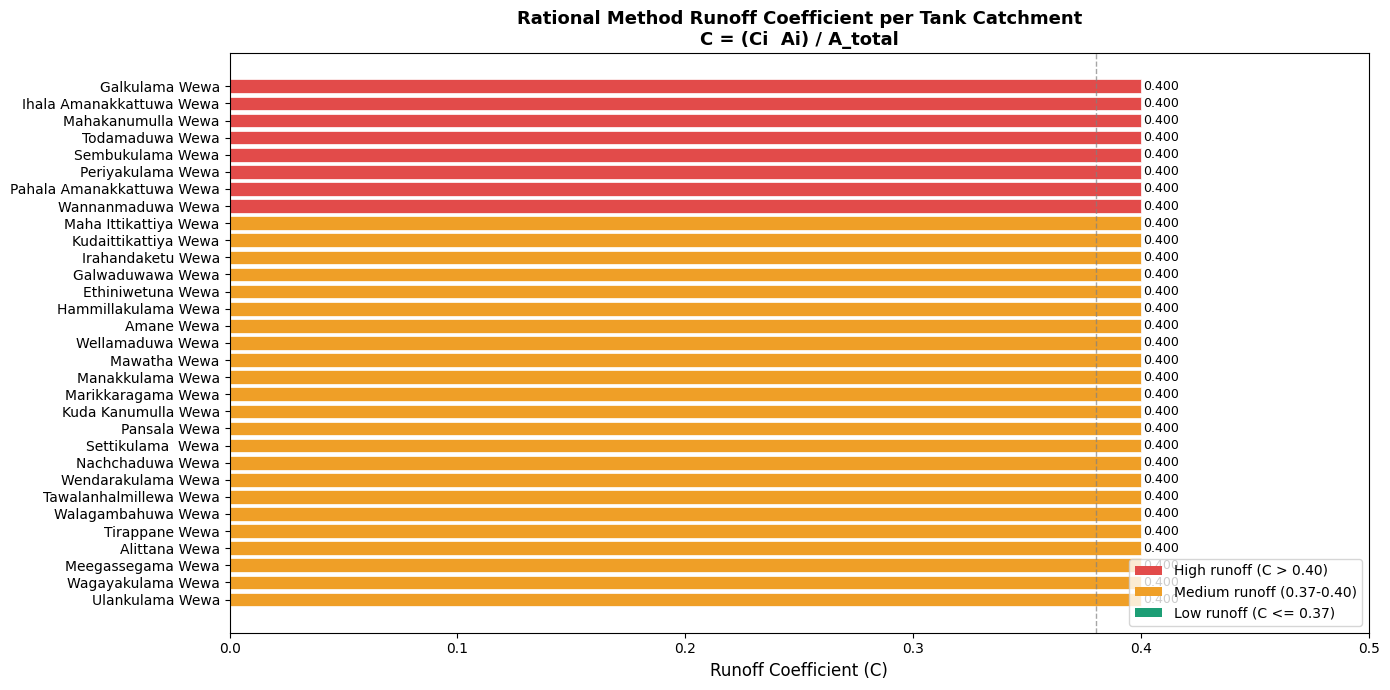

Saved runoff_coefficient_barchart.png


In [4]:
# Bar chart: Runoff Coefficient per Tank
output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 7))

colors = [
    "#E24B4A" if c > 0.40 else
    "#EF9F27" if c > 0.37 else
    "#1D9E75"
    for c in df_runoff["runoff_coefficient_C"]
]

bars = ax.barh(
    df_runoff["tank_name"],
    df_runoff["runoff_coefficient_C"],
    color=colors, edgecolor="white", linewidth=0.5
)

# Value labels
for bar, val in zip(bars, df_runoff["runoff_coefficient_C"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha="left", fontsize=9)

ax.set_xlabel("Runoff Coefficient (C)", fontsize=12)
ax.set_title(
    "Rational Method Runoff Coefficient per Tank Catchment\n"
    "C = (Ci  Ai) / A_total",
    fontsize=13,
    fontweight="bold"
)
ax.axvline(x=0.38, color="gray", linestyle="--", linewidth=1, alpha=0.7,
           label="Mean threshold (0.38)")
ax.legend(fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 0.50)

# Colour legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E24B4A", label="High runoff (C > 0.40)"),
    Patch(facecolor="#EF9F27", label="Medium runoff (0.37-0.40)"),
    Patch(facecolor="#1D9E75", label="Low runoff (C <= 0.37)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "runoff_coefficient_barchart.png", dpi=150)
plt.show()
print("Saved runoff_coefficient_barchart.png")


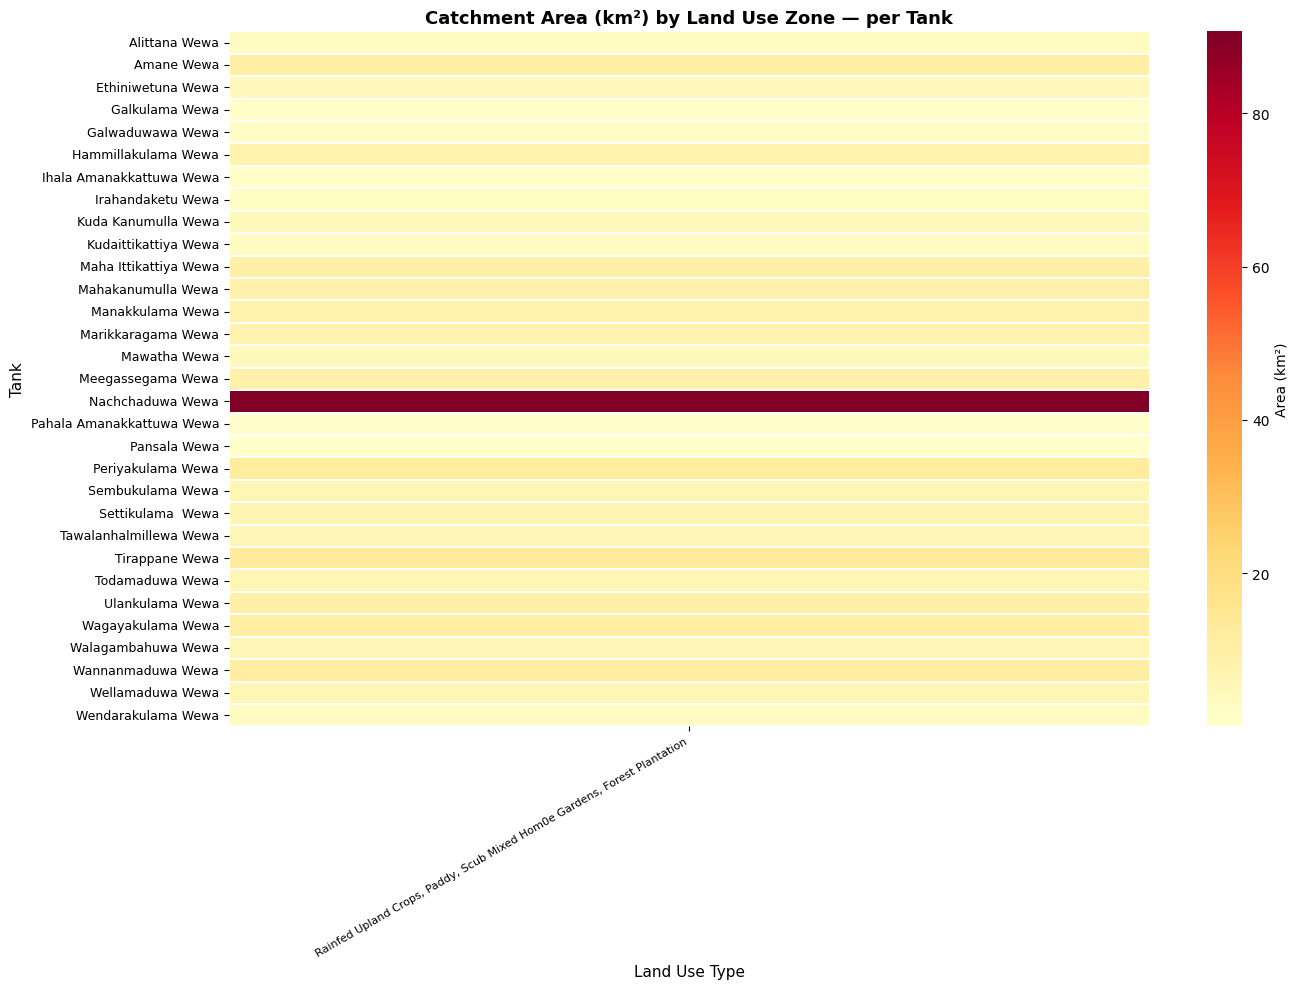

Saved catchment_landuse_heatmap.png


In [5]:
# ── Heatmap: breakdown of Ci by land use zone per tank ────────
pivot = df_tanks.pivot_table(
    index="pond_name",
    columns="land_use",
    values="sub_area_km2",
    aggfunc="sum",
    fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    annot=False,
    ax=ax,
    cbar_kws={"label": "Area (km²)"}
)
ax.set_title("Catchment Area (km²) by Land Use Zone — per Tank",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Land Use Type", fontsize=11)
ax.set_ylabel("Tank", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=8)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(output_dir / "catchment_landuse_heatmap.png", dpi=150)
plt.show()
print("Saved catchment_landuse_heatmap.png")

In [6]:
# Export results as CSV
df_export = df_runoff[[
    "rank","tank_name","runoff_coefficient_C",
    "A_total_km2","num_zones"
]].copy()

df_export.columns = [
    "Rank","Tank Name","Runoff Coefficient (C)",
    "Total Catchment Area (km)","No. of Agrozones"
]

# Styled display in notebook
styled = df_export.style.background_gradient(
    subset=["Runoff Coefficient (C)"], cmap="RdYlGn_r"
).format({"Runoff Coefficient (C)": "{:.4f}", "Total Catchment Area (km)": "{:.3f}"})

display(styled)

df_export.to_csv(output_dir / "runoff_coefficients.csv", index=False)
print(f"Saved runoff_coefficients.csv to {output_dir}")


,Rank,Tank Name,Runoff Coefficient (C),Total Catchment Area (km),No. of Agrozones
3,1,Galkulama Wewa,0.4000,1.302,4
6,2,Ihala Amanakkattuwa Wewa,0.4000,1.148,2
11,3,Mahakanumulla Wewa,0.4000,8.598,11
24,4,Todamaduwa Wewa,0.4000,5.773,9
20,5,Sembukulama Wewa,0.4000,6.152,2
19,6,Periyakulama Wewa,0.4000,12.270,31
17,7,Pahala Amanakkattuwa Wewa,0.4000,0.603,4
28,8,Wannanmaduwa Wewa,0.4000,11.123,19
10,9,Maha Ittikattiya Wewa,0.4000,9.357,10
9,10,Kudaittikattiya Wewa,0.4000,2.568,1


Saved runoff_coefficients.csv to C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\outputs


In [7]:
# Add runoff_coefficient_C to Phase 1 pickle
# This makes it available in Phase 2 (GNN node features) and Phase 3
import pickle

pkl_path = None
for folder in [project_root, *project_root.parents]:
    candidate = folder / "models" / "phase1_outputs.pkl"
    if candidate.exists():
        pkl_path = candidate
        break

if pkl_path is not None:
    with open(pkl_path, "rb") as f:
        p1 = pickle.load(f)

    # Merge runoff C into df_full
    df_full_updated = p1["df_full"].merge(
        df_runoff[["tank_name","runoff_coefficient_C","A_total_km2"]],
        on="tank_name", how="left"
    )
    p1["df_full"] = df_full_updated
    p1["df_runoff"] = df_runoff   # also save full runoff table

    with open(pkl_path, "wb") as f:
        pickle.dump(p1, f)

    print(f"{pkl_path} updated with runoff_coefficient_C")
    print()
    print("Runoff C added to", df_full_updated["runoff_coefficient_C"].notna().sum(),
          "tanks out of", len(df_full_updated))
else:
    print("WARNING: phase1_outputs.pkl not found.")
    print("Run 01_phase1_graph.ipynb first, then rerun this cell.")
    print()
    print("Runoff table saved as CSV  you can still use it independently.")


C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\models\phase1_outputs.pkl updated with runoff_coefficient_C

Runoff C added to 31 tanks out of 32


In [8]:
# ── Summary statistics ────────────────────────────────────────
print("=" * 55)
print("  RUNOFF COEFFICIENT SUMMARY — 32 TANKS")
print("=" * 55)
print(f"  Mean C   : {df_runoff['runoff_coefficient_C'].mean():.4f}")
print(f"  Min  C   : {df_runoff['runoff_coefficient_C'].min():.4f}  ({df_runoff.loc[df_runoff['runoff_coefficient_C'].idxmin(),'tank_name']})")
print(f"  Max  C   : {df_runoff['runoff_coefficient_C'].max():.4f}  ({df_runoff.loc[df_runoff['runoff_coefficient_C'].idxmax(),'tank_name']})")
print(f"  Std  C   : {df_runoff['runoff_coefficient_C'].std():.4f}")
print()
print(f"  High runoff (C > 0.40) : {(df_runoff['runoff_coefficient_C']>0.40).sum()} tanks")
print(f"  Medium    (0.37–0.40)  : {((df_runoff['runoff_coefficient_C']>=0.37) & (df_runoff['runoff_coefficient_C']<=0.40)).sum()} tanks")
print(f"  Low       (C < 0.37)   : {(df_runoff['runoff_coefficient_C']<0.37).sum()} tanks")
print("=" * 55)
print()
print("Top 5 highest runoff tanks (water managers should monitor):")
print(df_runoff.nlargest(5,"runoff_coefficient_C")[
    ["tank_name","runoff_coefficient_C","A_total_km2"]
].to_string(index=False))
print()
print("Top 5 lowest runoff tanks (more water retained in catchment):")
print(df_runoff.nsmallest(5,"runoff_coefficient_C")[
    ["tank_name","runoff_coefficient_C","A_total_km2"]
].to_string(index=False))


  RUNOFF COEFFICIENT SUMMARY — 32 TANKS
  Mean C   : 0.4000
  Min  C   : 0.4000  (Alittana Wewa)
  Max  C   : 0.4000  (Galkulama Wewa)
  Std  C   : 0.0000

  High runoff (C > 0.40) : 8 tanks
  Medium    (0.37–0.40)  : 23 tanks
  Low       (C < 0.37)   : 0 tanks

Top 5 highest runoff tanks (water managers should monitor):
               tank_name  runoff_coefficient_C  A_total_km2
          Galkulama Wewa                   0.4     1.302090
Ihala Amanakkattuwa Wewa                   0.4     1.148281
      Mahakanumulla Wewa                   0.4     8.597970
         Todamaduwa Wewa                   0.4     5.773251
        Sembukulama Wewa                   0.4     6.151585

Top 5 lowest runoff tanks (more water retained in catchment):
            tank_name  runoff_coefficient_C  A_total_km2
        Alittana Wewa                   0.4     2.506971
    Meegassegama Wewa                   0.4     8.873589
    Wagayakulama Wewa                   0.4    10.013834
      Ulankulama Wewa     